# 01 - Data Cleaning and Exploratory Analysis

**Rapido Intelligent Mobility Insights** - 100,000 bookings across five Indian cities, calendar year 2025.

This notebook profiles the five raw source files, cleans them, and establishes what actually drives
ride outcomes. Everything here calls the same functions the dashboard and the models use
(`src/data_preprocessing.py`), so nothing in this notebook can drift from the rest of the project.

**What this notebook establishes**

1. The data is structurally sound - no orphan foreign keys, no duplicate primary keys.
2. The only nulls are *structural*: columns that cannot exist until a ride resolves.
3. Three columns would leak the target if used naively. Each is identified and quarantined here.
4. Cancellations are driven by **traffic, weather and surge** - not by city or vehicle type.


In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["figure.dpi"] = 110


## 1. Load the raw data

Five CSVs, read through a single loader so dtypes are declared in one place.

In [2]:
import data_preprocessing as dp

raw = dp.load_all_raw()
pd.DataFrame(
    [{"dataset": k, "rows": f"{len(v):,}", "columns": v.shape[1]} for k, v in raw.items()]
)


,dataset,rows,columns
0,bookings,"100,000",22
1,customers,"10,000",13
2,drivers,"5,000",14
3,location_demand,"17,941",10
4,time_features,"8,760",7


In [3]:
raw["bookings"].head()


,booking_id,booking_date,booking_time,day_of_week,is_weekend,hour_of_day,city,pickup_location,drop_location,vehicle_type,ride_distance_km,estimated_ride_time_min,actual_ride_time_min,traffic_level,weather_condition,base_fare,surge_multiplier,booking_value,booking_status,incomplete_ride_reason,customer_id,driver_id
0,B_000001,2025-12-11,00:07:00,Thursday,0,0,Mumbai,Loc_19,Loc_16,Bike,7.01,46.30,NaN,High,Heavy Rain,76.12,2.0,148.22,Cancelled,NaN,C_005097,D_004592
1,B_000002,2025-07-07,06:13:00,Monday,0,6,Mumbai,Loc_32,Loc_38,Cab,9.67,43.54,42.28,Medium,Heavy Rain,254.15,1.8,465.85,Completed,NaN,C_008459,D_000148
2,B_000003,2025-08-23,08:53:00,Saturday,1,8,Chennai,Loc_28,Loc_1,Auto,16.18,48.55,NaN,Low,Heavy Rain,234.20,1.9,457.03,Cancelled,NaN,C_003471,D_004976
3,B_000004,2025-04-12,10:25:00,Saturday,1,10,Delhi,Loc_16,Loc_30,Bike,1.02,4.61,4.76,Medium,Rain,28.20,1.8,51.03,Completed,NaN,C_002161,D_001173
4,B_000005,2025-08-23,00:08:00,Saturday,1,0,Hyderabad,Loc_22,Loc_31,Bike,12.35,55.56,64.53,Medium,Clear,118.77,1.2,144.73,Completed,NaN,C_005617,D_001175


## 2. Profile every column

Dtype, null count, cardinality and range for all 66 columns across the five files.

In [4]:
profile = dp.profile_all_raw()
print(f"{len(profile)} columns profiled across {profile['dataset'].nunique()} datasets\n")
profile[profile["nulls"] > 0][["dataset", "column", "dtype", "nulls", "null_pct"]]


66 columns profiled across 5 datasets



,dataset,column,dtype,nulls,null_pct
12,bookings,actual_ride_time_min,float64,31654,31.65
19,bookings,incomplete_ride_reason,str,91630,91.63


### The null pattern is not random

Only two columns carry nulls, and both are *structural*: they describe what happened during a ride,
so they cannot exist for a ride that never happened.

This is the first leakage trap. `actual_ride_time_min` is null for **every** non-Completed booking,
so a model given that column could read the target straight off the null indicator.


In [5]:
bookings = raw["bookings"]
pd.crosstab(
    bookings["booking_status"],
    bookings["actual_ride_time_min"].isna().map({True: "null", False: "present"}),
)


actual_ride_time_min,null,present
booking_status,,
Cancelled,23284,0
Completed,0,68346
Incomplete,8370,0


## 3. Referential integrity and value ranges

In [6]:
integrity = dp.validate_referential_integrity(
    bookings.rename(columns=str.lower), raw["customers"], raw["drivers"]
)
print("Orphan foreign keys:", integrity)
print("Duplicate booking IDs:", int(bookings["Booking_ID"].duplicated().sum())
      if "Booking_ID" in bookings.columns else int(bookings.iloc[:, 0].duplicated().sum()))


Orphan foreign keys: {'orphan_customers': 0, 'orphan_drivers': 0}
Duplicate booking IDs: 0


## 4. Clean the data

Cleaning never invents values. The structural nulls above are *preserved* as NaN rather than imputed - imputing them would fabricate the very signal the models are meant to predict.

In [7]:
cleaned = dp.clean_all(raw)
dp.build_cleaning_summary(raw, cleaned)


,dataset,rows_before,rows_after,rows_removed,nulls_before,nulls_after,columns_after
0,bookings,100000,100000,0,123284,123284,23
1,customers,10000,10000,0,0,0,13
2,drivers,5000,5000,0,0,0,14
3,location_demand,17941,17941,0,0,0,11
4,time_features,8760,8760,0,0,0,7


In [8]:
bookings = cleaned["bookings"]
print("Value-range validation on the cleaned booking table:")
dp.validate_value_ranges(bookings, dp.BOOKING_RANGES)


Value-range validation on the cleaned booking table:


,column,expected_min,expected_max,actual_min,actual_max,violations,status
0,ride_distance_km,0.1,100.0,1.00,25.00,0,PASS
1,estimated_ride_time_min,1.0,300.0,3.00,164.98,0,PASS
2,actual_ride_time_min,1.0,300.0,2.75,197.34,0,PASS
3,base_fare,10.0,5000.0,28.02,529.96,0,PASS
4,surge_multiplier,1.0,3.0,1.00,2.30,0,PASS
5,booking_value,10.0,10000.0,27.28,1265.59,0,PASS
6,hour_of_day,0.0,23.0,0.00,23.00,0,PASS


## 5. The second leakage trap: fare is a formula

`base_fare` is not an observed quantity. It is exactly `flagfall + rate_per_km x distance`, and
`booking_value` is `base_fare x surge x (1 +- 5%)`. A fare model given `base_fare` is not
predicting anything - it is doing arithmetic.


In [9]:
rows = []
for vehicle, group in bookings.groupby("vehicle_type", observed=True):
    slope, intercept = np.polyfit(group["ride_distance_km"], group["base_fare"], 1)
    predicted = intercept + slope * group["ride_distance_km"]
    ss_res = float(((group["base_fare"] - predicted) ** 2).sum())
    ss_tot = float(((group["base_fare"] - group["base_fare"].mean()) ** 2).sum())
    rows.append({
        "vehicle_type": vehicle,
        "flagfall": round(intercept, 4),
        "rate_per_km": round(slope, 4),
        "r_squared": round(1 - ss_res / ss_tot, 6),
    })
pd.DataFrame(rows)


,vehicle_type,flagfall,rate_per_km,r_squared
0,Auto,40.0006,12.0000,1.0
1,Bike,20.0003,8.0000,1.0
2,Cab,79.9992,18.0001,1.0


In [10]:
implied = bookings["booking_value"] / (bookings["base_fare"] * bookings["surge_multiplier"])
print(f"booking_value / (base_fare x surge):  min={implied.min():.4f}  max={implied.max():.4f}")
print(f"Share within +-5%: {float(implied.between(0.95, 1.05).mean()):.4%}")
print("\nThe +-5% uniform noise is irreducible: it puts a floor of about 2.5% on any fare model's MAPE.")


booking_value / (base_fare x surge):  min=0.9499  max=1.0500
Share within +-5%: 99.9850%

The +-5% uniform noise is irreducible: it puts a floor of about 2.5% on any fare model's MAPE.


## 6. The third leakage trap: whole-period aggregates

`customers.cancellation_rate` and `drivers.delay_rate` are computed over *every* booking that
customer or driver ever made - including the one being predicted. The shipped `*_flag` columns are
just those rates thresholded, so they are the same leak wearing a different hat.


In [11]:
customers = cleaned["customers"]
print("customer_cancel_flag vs cancellation_rate:")
print(customers.groupby("customer_cancel_flag", observed=True)["cancellation_rate"].agg(["min", "max", "count"]))
print("\nThe flag is simply the rate thresholded - and the rate already contains the target.")


customer_cancel_flag vs cancellation_rate:
                           min  max  count
customer_cancel_flag                      
0                     0.000000  0.2   4657
1                     0.210526  1.0   5343

The flag is simply the rate thresholded - and the rate already contains the target.


## 7. Exploratory analysis

### 7.1 Outcome distribution


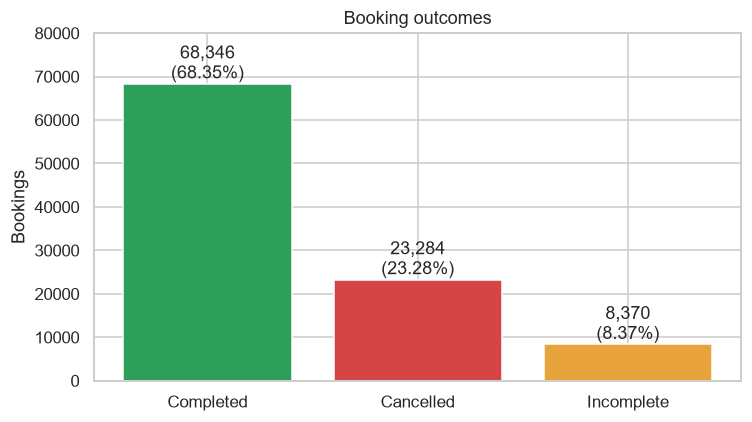

,bookings,share_pct
booking_status,,
Completed,68346,68.35
Cancelled,23284,23.28
Incomplete,8370,8.37


In [12]:
status_counts = bookings["booking_status"].value_counts()
share = (100 * status_counts / len(bookings)).round(2)
summary = pd.DataFrame({"bookings": status_counts, "share_pct": share})

fig, ax = plt.subplots(figsize=(7, 4))
colours = {"Completed": "#2E9E5B", "Cancelled": "#D64545", "Incomplete": "#E8A33D"}
ax.bar(summary.index, summary["bookings"], color=[colours[s] for s in summary.index])
for i, (n, p) in enumerate(zip(summary["bookings"], summary["share_pct"])):
    ax.text(i, n, f"{n:,}\n({p}%)", ha="center", va="bottom")
ax.set_title("Booking outcomes"); ax.set_ylabel("Bookings"); ax.set_ylim(0, 80000)
plt.tight_layout(); plt.show()
summary


### 7.2 What moves the cancellation rate?

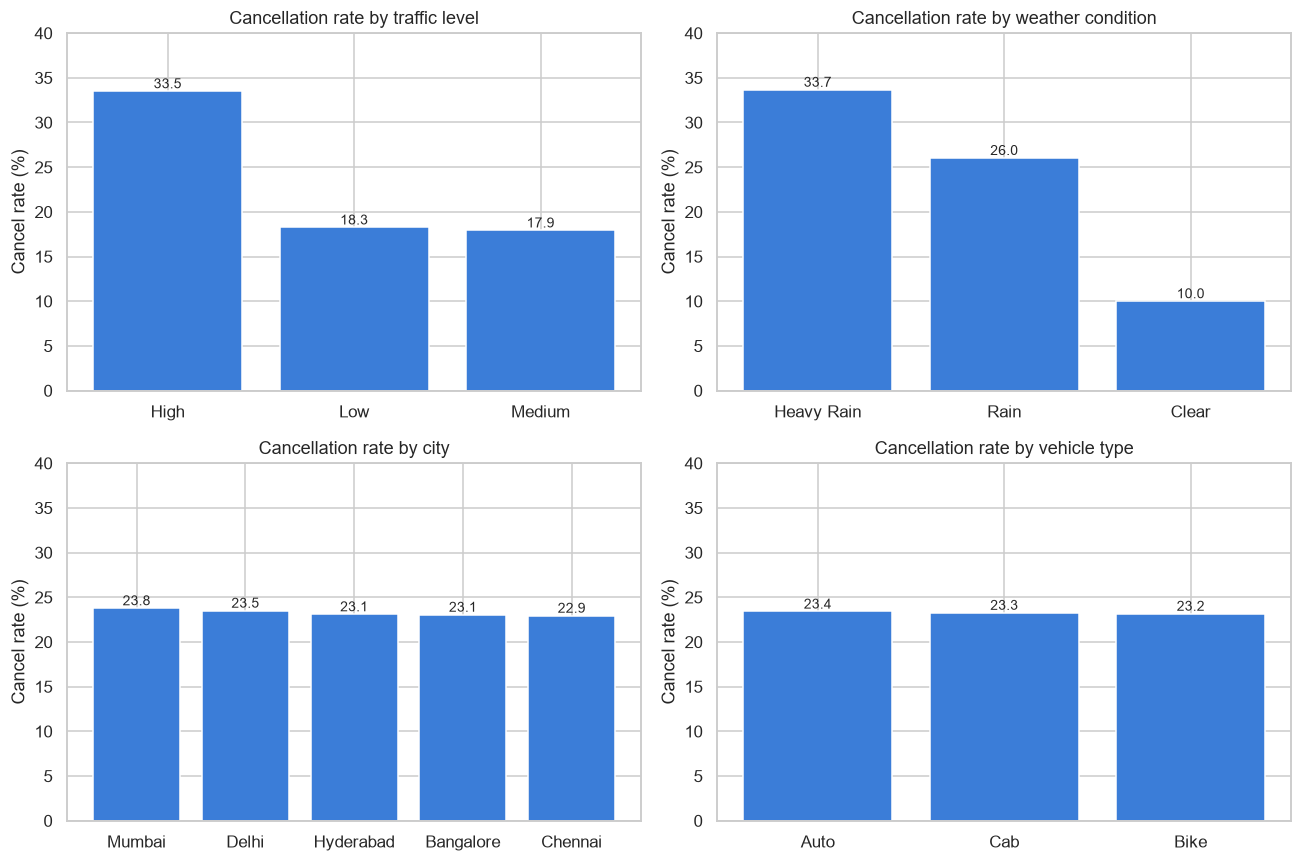

In [13]:
import feature_engineering as fe

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, column in zip(axes.ravel(), ["traffic_level", "weather_condition", "city", "vehicle_type"]):
    table = fe.cancellation_rate_by(bookings, column)
    ax.bar(table[column].astype(str), table["cancel_rate"], color="#3B7DD8")
    ax.set_title(f"Cancellation rate by {column.replace('_', ' ')}")
    ax.set_ylabel("Cancel rate (%)"); ax.set_ylim(0, 40)
    for i, v in enumerate(table["cancel_rate"]):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


The contrast is the headline finding of the whole project:

- **Traffic** moves cancellations from ~18% to **33.5%**
- **Weather** moves them from 10.0% to **33.7%**
- **City** varies by less than one percentage point
- **Vehicle type** varies by less than one percentage point

Geography and vehicle choice are not the problem. Conditions are.


### 7.3 Surge is the strongest single lever

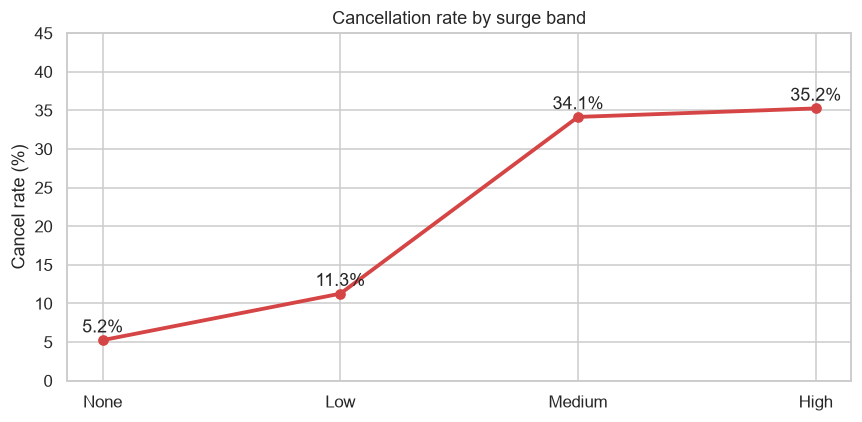

,surge_bucket,rides,cancel_rate,incomplete_rate
0,None,7950,5.25,4.74
1,Low,37760,11.27,7.22
2,Medium,47856,34.15,9.70
3,High,6434,35.25,9.70


In [14]:
banded = fe.add_surge_bucket(bookings)
surge_table = fe.cancellation_rate_by(banded, "surge_bucket").sort_values("surge_bucket")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(surge_table["surge_bucket"].astype(str), surge_table["cancel_rate"],
        marker="o", linewidth=2.5, color="#D64545")
for x, y in zip(surge_table["surge_bucket"].astype(str), surge_table["cancel_rate"]):
    ax.text(x, y + 1, f"{y:.1f}%", ha="center")
ax.set_title("Cancellation rate by surge band"); ax.set_ylabel("Cancel rate (%)"); ax.set_ylim(0, 45)
plt.tight_layout(); plt.show()
surge_table


### 7.4 Cancellations and incompletions are different problems

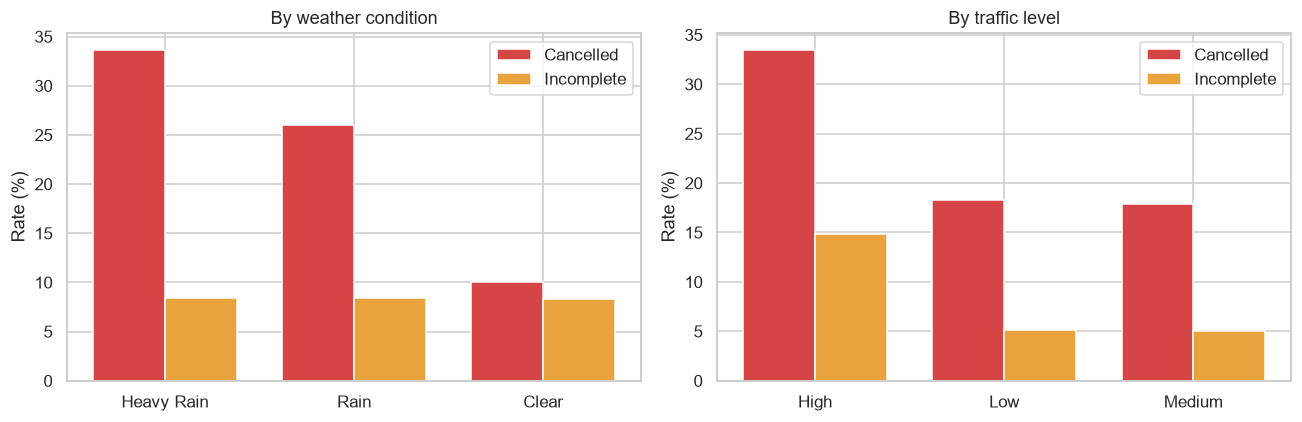

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, column in zip(axes, ["weather_condition", "traffic_level"]):
    table = fe.cancellation_rate_by(bookings, column)
    x = np.arange(len(table)); width = 0.38
    ax.bar(x - width/2, table["cancel_rate"], width, label="Cancelled", color="#D64545")
    ax.bar(x + width/2, table["incomplete_rate"], width, label="Incomplete", color="#E8A33D")
    ax.set_xticks(x); ax.set_xticklabels(table[column].astype(str))
    ax.set_title(f"By {column.replace('_', ' ')}"); ax.set_ylabel("Rate (%)"); ax.legend()
plt.tight_layout(); plt.show()


Incomplete rates are **flat across weather** (8.3-8.4%) but move sharply **with traffic** (5.1% to 14.8%).

Riders abandon bookings in bad weather. Drivers fail to complete them in bad traffic. Two distinct
failure modes needing two distinct interventions.


### 7.5 Demand across the day

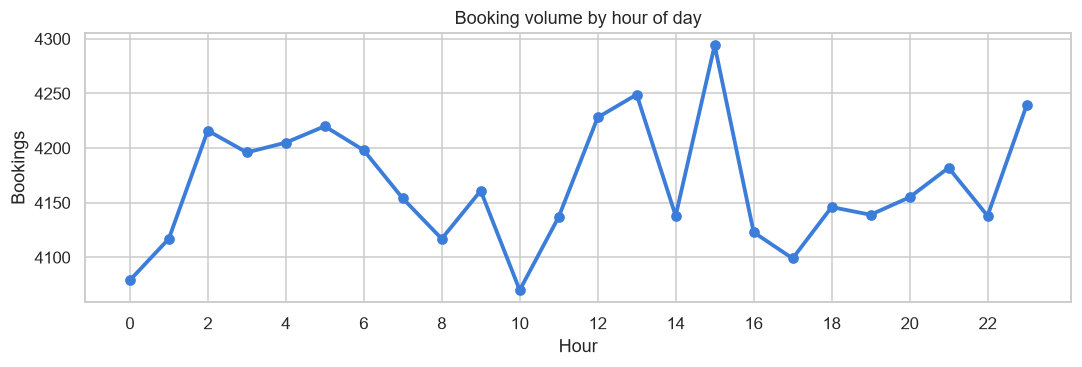

In [16]:
hourly = bookings.assign(hour=bookings["booking_ts"].dt.hour).groupby("hour").size()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(hourly.index, hourly.values, marker="o", color="#3B7DD8", linewidth=2.5)
ax.set_title("Booking volume by hour of day"); ax.set_xlabel("Hour"); ax.set_ylabel("Bookings")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()


## 8. Statistical significance

On 100,000 rows, chi-square p-values collapse toward zero for almost any association, so effect size (Cramer's V) is what separates a real driver from a trivial one.

In [17]:
results = fe.run_standard_tests(bookings)
fe.summarise_tests(results)


,test,variables,statistic,p_value,effect_size,conclusion
0,Chi-square test of independence,traffic_level vs booking_status,6869.6246,< 0.0001,0.1853,significant (reject H0)
1,Chi-square test of independence,weather_condition vs booking_status,5622.0518,< 0.0001,0.1677,significant (reject H0)
2,Chi-square test of independence,vehicle_type vs booking_status,2.2017,0.6987,0.0033,not significant (retain H0)
3,Chi-square test of independence,city vs booking_status,8.3752,0.3977,0.0065,not significant (retain H0)
4,One-way ANOVA,booking_value across vehicle_type,27763.2822,< 0.0001,-,significant (reject H0)
5,One-way ANOVA,surge_multiplier across traffic_level,17148.8523,< 0.0001,-,significant (reject H0)
6,Welch's two-sample t-test,booking_value by weekend_label,-0.1030,0.9179,-0.0007,not significant (retain H0)


The tests confirm what the charts showed: **traffic and weather are significant with meaningful
effect sizes**, while **city (p = 0.40) and vehicle type (p = 0.70) are not significant at all**.

## Conclusions

| Finding | Evidence |
|---|---|
| Data is structurally sound | 0 orphan FKs, 0 duplicate keys |
| Nulls are structural, not missing data | Only in post-outcome columns; 100% aligned with booking status |
| `actual_ride_time_min` leaks the target | Null for every non-Completed ride |
| Fare is a deterministic tariff | R² = 1.000000 per vehicle; ±5% noise floor |
| Shipped rate columns leak | Whole-period aggregates including the predicted row |
| Traffic and weather drive cancellations | 33.5% and 33.7% vs ~10-18% baselines |
| City and vehicle do **not** | chi-square p = 0.40 and p = 0.70 |
| Surge is the strongest lever | 5.3% at 1.0x to 35.3% above 2.0x |

Next: **`02_feature_engineering.ipynb`** builds the model-ready feature table, replacing the leaky
aggregates with leakage-safe prior-history features.
